### 2 b) Impact of $Z_c$ variation regarding pathological states
In the $WK_3$ model, the characteristic impedance ($Z_c$) represents the physical state of the aortic root. Systemic changes affect this input impedance:
1. **Aging and Hypertension:** They imply an increase in aortic stiffness, which translates into a higher characteristic impedance ($Z_c \uparrow$). This causes a worsening in the impedance matching between the ventricle and the aorta.
2. **Septic Shock:** Profound vasodilation relaxes the aortic wall, decreasing the characteristic impedance ($Z_c \downarrow$).

Next, we will simulate the three scenarios comparing the curve with a normal $Z_c$ against the curve with a pathologically altered $Z_c$.

### 2 b) Complete analysis: $WK_2$ vs $WK_3$ in pathological states
In this section, we will analyze the impact of the **Characteristic Impedance ($Z_c$)** on the three previously studied pathological states.

For each disease, we will compare three scenarios:
1. The **$WK_2$** model (without $Z_c$), where the aortic pressure is completely "smoothed" by compliance.
2. The **$WK_3$** model assuming a healthy aortic root (normal $Z_c$).
3. The **$WK_3$** model with the aortic root affected by the pathology (pathological $Z_c$).

**Expected alterations of $Z_c$:**
* **Aging and Hypertension:** The aortic root stiffens, which increases the impedance mismatch ($Z_c \uparrow$).
* **Septic Shock:** Profound vasodilation relaxes the tissues, reducing the input impedance ($Z_c \downarrow$).

In [1]:
# -------------------------------------------------------------------------
# MODULES AND FLOW FUNCTION
# -------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

def Q_Sim(Qmax, T, t):
    Escala_ml = 1e5 * (Qmax / 8.8)
    Q = Escala_ml * ((7.9853e-06 + 2.6617e-05*np.sin(2*np.pi*t/T+0.29498) +
                      2.3616e-05*np.sin(4*np.pi*t/T-1.1403) - 1.9016e-05*np.sin(6*np.pi*t/T+0.40435) -
                      8.5899e-06*np.sin(8*np.pi*t/T-1.1892) - 2.436e-06*np.sin(10*np.pi*t/T-1.4918) +
                      1.4905e-06*np.sin(12*np.pi*t/T+1.0536) + 1.3581e-06*np.sin(14*np.pi*t/T-0.47666) -
                      6.3031e-07*np.sin(16*np.pi*t/T+0.93768) - 4.5335e-07*np.sin(18*np.pi*t/T-0.79472) -
                      4.5184e-07*np.sin(20*np.pi*t/T-1.4095) - 5.6583e-07*np.sin(22*np.pi*t/T-1.3629) +
                      4.9522e-07*np.sin(24*np.pi*t/T+0.52495) + 1.3049e-07*np.sin(26*np.pi*t/T-0.97261) -
                      4.1072e-08*np.sin(28*np.pi*t/T-0.15685) - 2.4182e-07*np.sin(30*np.pi*t/T-1.4052) -
                      6.6217e-08*np.sin(32*np.pi*t/T-1.3785) - 1.5511e-07*np.sin(34*np.pi*t/T-1.2927) +
                      2.2149e-07*np.sin(36*np.pi*t/T+0.68178) + 6.7621e-08*np.sin(38*np.pi*t/T-0.98825) +
                      1.0973e-07*np.sin(40*np.pi*t/T+1.4327) - 2.5559e-08*np.sin(42*np.pi*t/T-1.2372) -
                      3.5079e-08*np.sin(44*np.pi*t/T+0.2328)))
    return Q

In [2]:
# -------------------------------------------------------------------------
# INTEGRATING FUNCTIONS: WK2 AND WK3 (With variable initial pressure)
# -------------------------------------------------------------------------

def resolver_wk2_euler(Q, t, Ca, Rp, P0=80.0):
    dt = t[1] - t[0]
    P = np.zeros(len(t))
    P[0] = P0
    for i in range(1, len(t)):
        dP_dt = (Q[i-1] / Ca) - (P[i-1] / (Rp * Ca))
        P[i] = P[i-1] + (dP_dt * dt)
    return P

def resolver_wk3_euler(Q, t, Ca, Rp, Zc, P0=80.0):
    dt = t[1] - t[0]
    Pc = np.zeros(len(t))
    P_ao = np.zeros(len(t))

    Pc[0] = P0
    P_ao[0] = Pc[0] + (Q[0] * Zc)

    for i in range(1, len(t)):
        dP_dt = (Q[i-1] / Ca) - (Pc[i-1] / (Rp * Ca))
        Pc[i] = Pc[i-1] + (dP_dt * dt)
        P_ao[i] = Pc[i] + (Q[i] * Zc)

    return P_ao

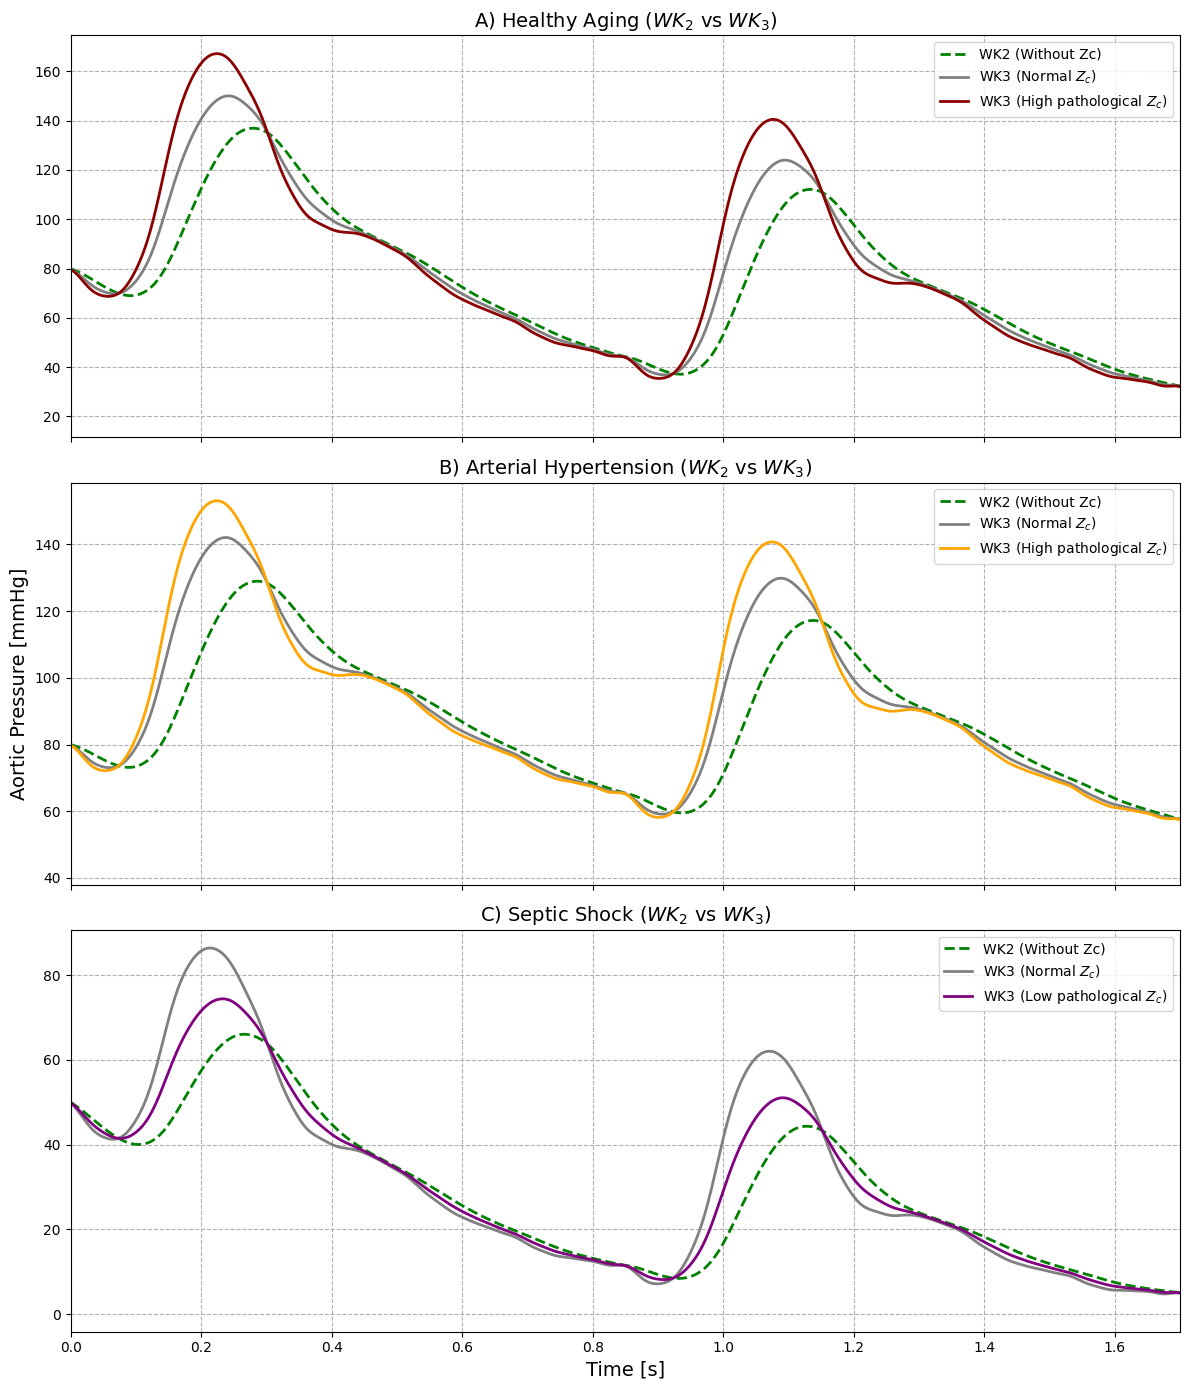

In [3]:
# -------------------------------------------------------------------------
# SIMULATION 2b: COMPARISON WK2 vs WK3 IN THE THREE STATES
# -------------------------------------------------------------------------

# 1. Time and Flow Vectors
Ts = 0.001
t = np.arange(0, 5, Ts)
Q_entrada = Q_Sim(Qmax=500, T=0.85, t=t)

# 2. General Baseline Parameters
Ca_basal = 1.1
Rp_basal = 0.9
Zc_normal = 0.06

# --- STATE 1: AGING ---
Ca_env, Rp_env = Ca_basal * 0.60, Rp_basal * 1.30
Zc_env_alto = Zc_normal * 1.80  # Increase due to stiffness
P_env_wk2 = resolver_wk2_euler(Q_entrada, t, Ca_env, Rp_env)
P_env_wk3_norm = resolver_wk3_euler(Q_entrada, t, Ca_env, Rp_env, Zc_normal)
P_env_wk3_alt = resolver_wk3_euler(Q_entrada, t, Ca_env, Rp_env, Zc_env_alto)

# --- STATE 2: HYPERTENSION ---
Ca_hta, Rp_hta = Ca_basal * 0.80, Rp_basal * 1.70
Zc_hta_alto = Zc_normal * 1.50  # Increase due to wall tension
P_hta_wk2 = resolver_wk2_euler(Q_entrada, t, Ca_hta, Rp_hta)
P_hta_wk3_norm = resolver_wk3_euler(Q_entrada, t, Ca_hta, Rp_hta, Zc_normal)
P_hta_wk3_alt = resolver_wk3_euler(Q_entrada, t, Ca_hta, Rp_hta, Zc_hta_alto)

# --- STATE 3: SEPTIC SHOCK (Low initial condition P0=50) ---
Ca_sep, Rp_sep = Ca_basal * 1.20, Rp_basal * 0.40
Zc_sep_bajo = Zc_normal * 0.50  # Decrease due to vasodilation
P_sep_wk2 = resolver_wk2_euler(Q_entrada, t, Ca_sep, Rp_sep, P0=50.0)
P_sep_wk3_norm = resolver_wk3_euler(Q_entrada, t, Ca_sep, Rp_sep, Zc_normal, P0=50.0)
P_sep_wk3_bajo = resolver_wk3_euler(Q_entrada, t, Ca_sep, Rp_sep, Zc_sep_bajo, P0=50.0)

# -------------------------------------------------------------------------
# VISUALIZATION IN THREE SUBPLOTS
# -------------------------------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# 1. Aging
axs[0].plot(t, P_env_wk2, '--', color='green', linewidth=2, label='WK2 (Without Zc)')
axs[0].plot(t, P_env_wk3_norm, 'gray', linewidth=2, label='WK3 (Normal $Z_c$)')
axs[0].plot(t, P_env_wk3_alt, 'darkred', linewidth=2, label='WK3 (High pathological $Z_c$)')
axs[0].set_title('A) Healthy Aging ($WK_2$ vs $WK_3$)', fontsize=14)
axs[0].legend(loc='upper right')
axs[0].grid(True, linestyle='--')

# 2. Hypertension
axs[1].plot(t, P_hta_wk2, '--', color='green', linewidth=2, label='WK2 (Without Zc)')
axs[1].plot(t, P_hta_wk3_norm, 'gray', linewidth=2, label='WK3 (Normal $Z_c$)')
axs[1].plot(t, P_hta_wk3_alt, 'orange', linewidth=2, label='WK3 (High pathological $Z_c$)')
axs[1].set_title('B) Arterial Hypertension ($WK_2$ vs $WK_3$)', fontsize=14)
axs[1].set_ylabel('Aortic Pressure [mmHg]', fontsize=14)
axs[1].legend(loc='upper right')
axs[1].grid(True, linestyle='--')

# 3. Septic Shock
axs[2].plot(t, P_sep_wk2, '--', color='green', linewidth=2, label='WK2 (Without Zc)')
axs[2].plot(t, P_sep_wk3_norm, 'gray', linewidth=2, label='WK3 (Normal $Z_c$)')
axs[2].plot(t, P_sep_wk3_bajo, 'purple', linewidth=2, label='WK3 (Low pathological $Z_c$)')
axs[2].set_title('C) Septic Shock ($WK_2$ vs $WK_3$)', fontsize=14)
axs[2].set_xlabel('Time [s]', fontsize=14)
axs[2].legend(loc='upper right')
axs[2].grid(True, linestyle='--')

# Adjust X limits to observe the first two beats in detail
plt.xlim(0, 1.7)
plt.tight_layout()
plt.show()

### Conclusions of the $Z_c$ variation
The term that dominates the rapid changes in the signal is the instantaneous voltage drop $Q(t) \cdot Z_c$.

1. **Aging and Hypertension:** Increasing $Z_c$ produces a severe **impedance mismatch** at the onset of ventricular injection. Blood flow crashes against a very stiff wall (high impedance), which causes the systolic peak to spike sharply. From the point of view of cardiac work, this forces the ventricle to consume much more instantaneous power to eject the same volume.
2. **Septic Shock:** By decreasing $Z_c$ due to profound vasodilation, the system offers even less initial resistance to the flow wave. The coupling is so "loose" that the wave loses its characteristic sharp peak, and the maximum systolic pressure is depressed, worsening the overall hypotension.

### Conclusions of the $WK_2$ vs $WK_3$ comparison

The superposition of both models allows us to clearly see the "error" or omission of the $WK_2$:

1. **The defect of $WK_2$:** In all graphs, the $WK_2$ curve (dotted green) shows an artificially smooth systolic rise. All the energy of the incoming flow is ideally filtered by the "capacitor" ($C_A$), ignoring the local inertia and stiffness of the site where blood is injected.

2. **The addition of $Z_c$ in high-pressure pathologies:** Both in aging and hypertension, by incorporating the $WK_3$ with the $Z_c$ exacerbated by vascular stiffness (red and orange curves), we observe an early "spike" in systole. This steep slope ($Q(t) \cdot Z_c$) explains the sharp systolic peaks clinically measured in elderly and hypertensive patients, which requires the heart to work much harder to overcome that initial barrier.

3. **The addition of $Z_c$ in hypotension (Shock):** In septic shock, the highly dilated aortic wall decreases the value of $Z_c$. The difference between the normal and pathological $WK_3$ shows us that this "failure of vascular tone" excessively dampens the initial impulse of the blood (the purple peak is lower than the gray peak), reflecting a loss of pulsatile force that aggravates the clinical picture.